In [1]:
# imports
import os
import numpy as np
import mat73
import matplotlib.pyplot as plt
import SensoriMotorPrediction.globals as gl

Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/
Atlases dir found: atlases


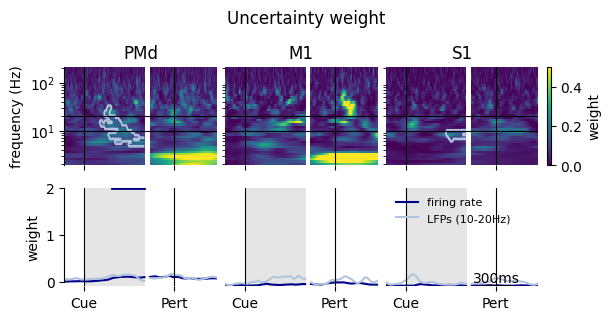

In [2]:
rois = ['PMd', 'M1', 'S1']

fig, axs_ = plt.subplots(2, len(rois)+1, sharex='col', figsize=(6, 3), gridspec_kw={"width_ratios": [80] * len(rois) + [2]}, constrained_layout=True)

axs = axs_[:, :-1]
ax_c = axs_[:, -1]

freq1, freq2 = 10, 20
cfg = mat73.loadmat(os.path.join('data','LFPs','cfg.mat'))['cfg']
foi = cfg['foi']
freq_mask = (foi > freq1) & (foi < freq2)
t_cue = np.linspace(0, gl.cuePost - 1, gl.cuePost)
t_pert = np.linspace(gl.pertPre, gl.pertPost - 1, gl.pertPost - gl.pertPre) + 5
t = np.concatenate((t_cue, t_pert))

vmin, vmax = 0, .5
model = 'Uncertainty'
for r, roi in enumerate(rois):
    weight_lfp = np.load(os.path.join(gl.nhpDir, gl.pcmDir, f'weight.lfp.{roi}.plan.npy'))[..., 1].mean(axis=0)
    weight_lfp_band = weight_lfp[freq_mask].mean(axis=0)
    sig_lfp1 = np.load(os.path.join(gl.nhpDir, gl.pcmDir, f'significant_bf.lfp.Cue.{roi}.plan.npy'))
    sig_lfp1 = sig_lfp1[..., 1]
    weight_lfp1 = weight_lfp[:, :gl.cuePost]
    weight_lfp2 = weight_lfp[:, gl.pertPre:]
    weight_lfp_band1 = weight_lfp_band[:gl.cuePost]
    weight_lfp_band2 = weight_lfp_band[gl.pertPre:]
    h1 = axs[0, r].pcolormesh(t_cue, foi, weight_lfp1, vmin=vmin, vmax=vmax, cmap='viridis')
    h1.set_rasterized(True)
    axs[0, r].contour(t_cue, foi, sig_lfp1, levels=1, colors='lightsteelblue', linewidths=1)
    h2 = axs[0, r].pcolormesh(t_pert, foi, weight_lfp2, vmin=vmin, vmax=vmax, cmap='viridis')
    h2.set_rasterized(True)
    axs[0, r].set_yscale('log')
    axs[0, r].set_title(roi)
    axs[0, r].axhline(freq1, color='k', lw='.8')
    axs[0, r].axhline(freq2, color='k', lw='.8')
    axs[0, r].set_ylabel('frequency (Hz)') if r==0 else None
    weight_spk = np.load(os.path.join(gl.nhpDir, gl.pcmDir, f'weight.spk.{roi}.plan.npy'))[..., 1].mean(axis=0)
    weight_spk1 = weight_spk[:gl.cuePost]
    weight_spk2 = weight_spk[gl.pertPre:]
    sig_spk1 = np.load(os.path.join(gl.nhpDir, gl.pcmDir, f'significant_bf.spk.Cue.{roi}.plan.npy'))
    sig_spk1 = sig_spk1[..., 1]
    sig_spk1[sig_spk1<1] = np.nan
    sig_spk1[sig_spk1==1] = 2
    axs[1, r].plot(t_cue, sig_spk1, color='darkblue', lw=2)
    axs[1, r].plot(t_cue, weight_spk1, color='darkblue', label='firing rate')
    axs[1, r].plot(t_pert, weight_spk2, color='darkblue')
    axs[1, r].plot(t_cue, weight_lfp_band1, color='lightsteelblue', label='LFPs (10-20Hz)')
    axs[1, r].plot(t_pert, weight_lfp_band2, color='lightsteelblue')
    axs[1, r].axvspan(gl.cueIdx, gl.cuePost, color='grey', alpha=.2, lw=0)
    axs[1, r].set_ylim([None, 2])
    axs[1, r].set_yticks((0, 1, 2))
    axs[1, r].spines['left'].set_bounds(0, 2)
    axs[1, r].set_ylabel('weight') if r==0 else None
    for i in range(2):
        axs[i, r].axvline(gl.cueIdx, color='k', lw='.8')
        axs[i, r].axvline(gl.pertIdx, color='k', lw='.8')
        axs[i, r].set_xticks([gl.cueIdx, gl.pertIdx])
        axs[i, r].set_xticklabels(['Cue', 'Pert'])
        axs[i, r].set_yticks([]) if r>0 else None
        axs[i, r].spines[['bottom', 'right', 'top']].set_visible(False) if r==0 else axs[i, r].spines[['bottom', 'right', 'top', 'left']].set_visible(False)

axs[1, -1].legend(frameon=False, ncol=1, fontsize=8, loc='upper left')
axs[1, -1].hlines(0, xmin=100, xmax=130, color='k', lw=2)
axs[1, -1].text(115, 0, '300ms', fontsize=10, color='k', va='bottom', ha='center')

fig.colorbar(h2, cax=ax_c[0], label='weight')
for ax in ax_c[1:]:
    ax.remove()

fig.suptitle(f'{model} weight', va='center')

fig.savefig(os.path.join('figures', 'ephys.uncertainty.plan.weight.pdf'))

plt.show()